# WFS controls for operation at ALS beamline 5.3.1
francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We want to: 
+ control a stage using the ALS BCS software TCP server
+ control a thorlabs stage using ophyd websocket


## Connect to the BCS

In [ ]:
# location of a berkeley lab specific python to reac labview through tcp port
#sys.path.append("C:\\Users\\lbnl-guest\\python")
import bcs_tcp

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP,55000,5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Identify strings
bcs_id_linear = 'Galil x.20 A'  # linear stage
bcs_id_rotary = 'Galil x.20 B'  # rotary stage

In [ ]:
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 13.0 mm


## Connect to basler camera

In [ ]:
# from pypylon import pylon

# WFS_CAMERA_IP = "192.168.10.204"

# tl_factory = pylon.TlFactory.GetInstance()

# # Create a device info object and set the IP address
# device_info = pylon.DeviceInfo()
# device_info.SetDeviceClass("BaslerGigE")  # Ensure we target GigE cameras
# device_info.SetIpAddress(WFS_CAMERA_IP)
# #acA1920-25gc

# # Try to create the camera object
# camera = pylon.InstantCamera(tl_factory.CreateDevice(device_info))

In [ ]:
# camera.Open()
# print(f"Connected to camera: {camera.GetDeviceInfo().GetModelName()}")

Connected to camera: acA5472-5gm


In [3]:
import epics
#epics.caput("BL531acA5427:cam1:SizeX",100)
#epics.caput("BL531acA5427:cam1:SizeY",100)

epics.caget("BL531acA5427:cam1:ArraySizeY_RBV")

3672

In [22]:

# we struggled a little bit with cam1 vs. image one, capitalization, columns and dots. now we're good ... hopefully ...
from time import sleep
epics.caput("BL531acA5427:cam1:Acquire",1)
data  = epics.caget("BL531acA5427:image1:ArrayData")
size_x = epics.caget("BL531acA5427:cam1:ArraySizeX_RBV")
size_y = epics.caget("BL531acA5427:cam1:ArraySizeY_RBV")
image = data.reshape((size_y, size_x))




In [23]:
print(image.shape)

(1000, 3000)


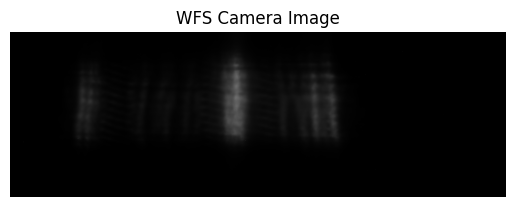

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(image, cmap='gray')
plt.title('WFS Camera Image')
plt.axis('off')
plt.show()  

In [32]:
bcs.MoveMotor(bcs_id_linear,36)

'Move Started\r\n'

In [ ]:
import numpy as np
from time import sleep

size_x = epics.caget("BL531acA5427:cam1:ArraySizeX_RBV")
size_y = epics.caget("BL531acA5427:cam1:ArraySizeY_RBV")

pos_start_mm = 36.0
pos_end_mm = 0.0
pos_step_mm = 0.1
N_steps = int(np.abs(pos_end_mm - pos_start_mm) / pos_step_mm) + 1
positions_mm = np.linspace(pos_start_mm, pos_end_mm, num=N_steps)
data_collected = []
for i_p in range(N_steps):
    pos_mm = positions_mm[i_p]
    bcs.MoveMotor(bcs_id_linear,pos_mm)
    sleep(1)  # wait for the stage to move
    #print(f"Moved to position {pos_mm:.1f} mm")
    epics.caput("BL531acA5427:cam1:Acquire",1)
    # wait for acquisition to complete BL531acA5427:cam1:Acquire_RBV = 0 when done
    while epics.caget("BL531acA5427:cam1:Acquire_RBV") == 1:
        sleep(0.5)
    sleep(5)
    data  = epics.caget("BL531acA5427:image1:ArrayData")
    image = data.reshape((size_y, size_x))
    filename  = "../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_%03i" %i_p
    np.save(filename,image)
    print(f"Saved image at position {pos_mm:.1f} mm to {filename}.npy")


Saved image at position 36.0 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_000.npy
Saved image at position 35.9 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_001.npy
Saved image at position 35.8 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_002.npy
Saved image at position 35.7 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_003.npy
Saved image at position 35.6 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_004.npy
Saved image at position 35.5 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_005.npy
Saved image at position 35.4 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_006.npy
Saved image at position 35.3 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_007.npy
Saved image at position 35.2 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_008.npy
Saved image at position 35.1 mm to ../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_009.npy
Saved image at position 35.0 mm to ../data/2026031

In [3]:
import numpy as np
data_list = []
for i_p in range(361):
    data_list.append(np.load('../data/20260310_ALS531_WFS/20260310_ALS531_WFS_001_%03i.npy' %i_p))

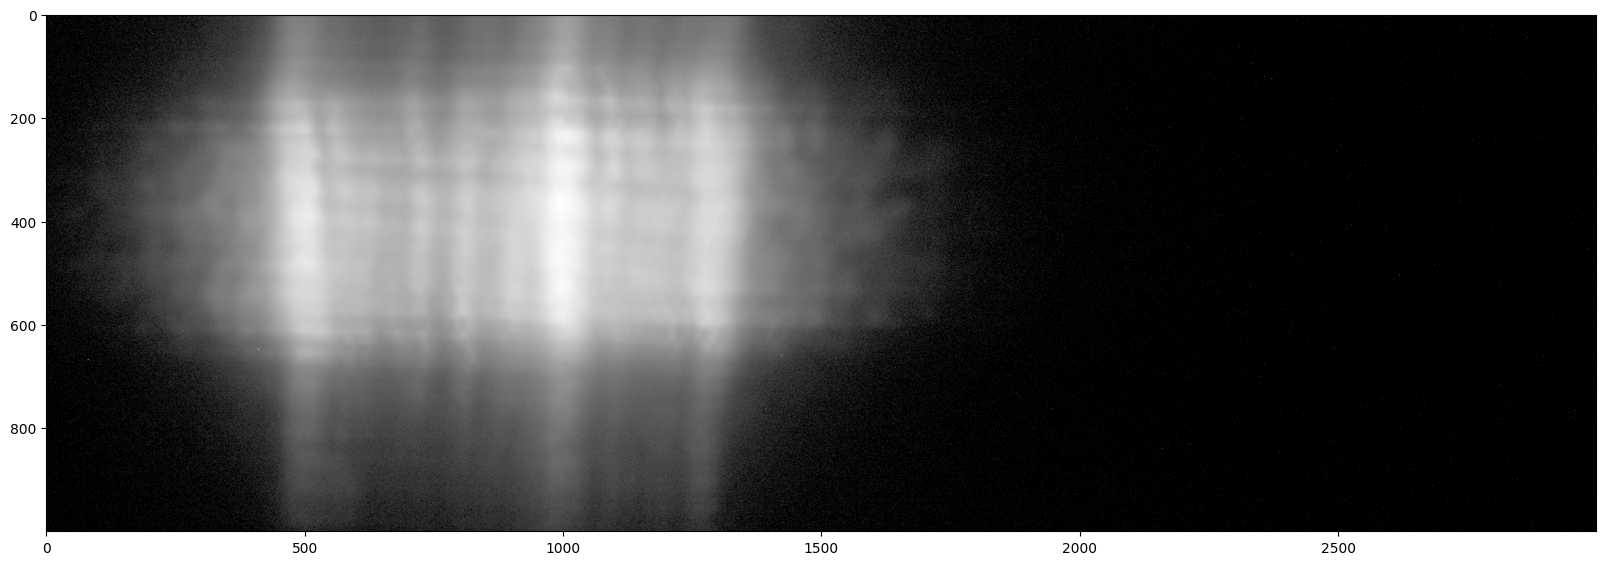

In [65]:
plt.figure(figsize=(20, 20))
plt.imshow(np.log(data_list[200]+1), cmap='gray')
plt.show()

In [ ]:
# stitched_image = np.vstack(data_list)
# plt.imshow(stitched_image, cmap='gray')
# plt.title('Stitched Image')
# plt.axis('off')
# plt.show()

: 

In [ ]:
# pixel sie for aCA5427-5gm


Pixel stride in pixels: 41.7 px


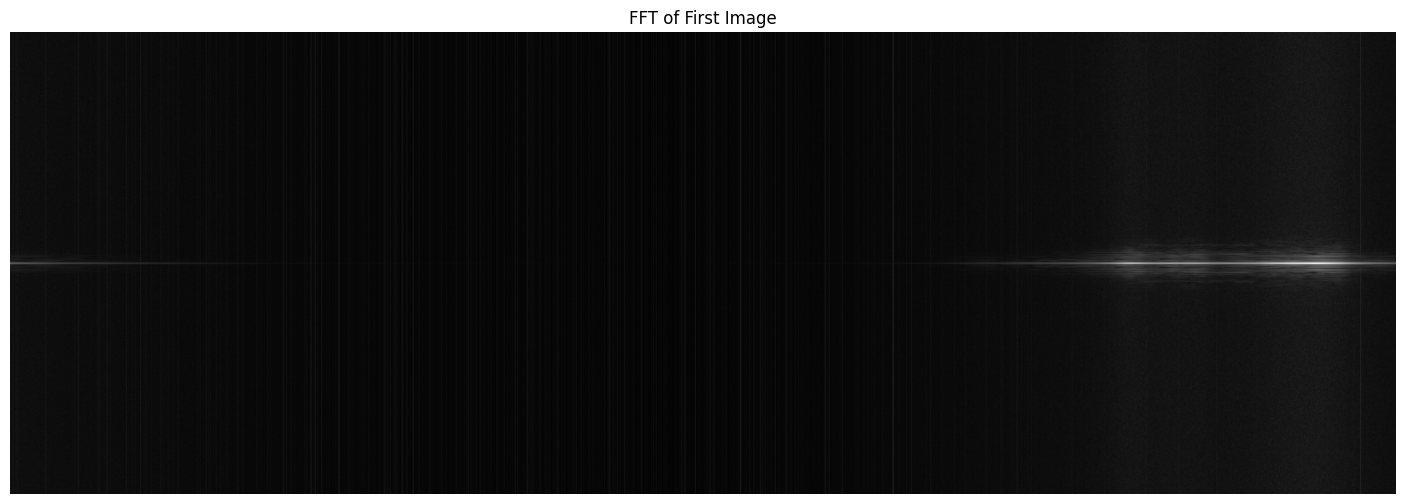

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
fft_image = np.fft.fftshift(np.fft.fft(data_list[50], axis = 0))
plt.figure(figsize=(18,6))
plt.imshow((np.abs(fft_image))**0.3, cmap='gray')
plt.title('FFT of First Image')
plt.axis('off')
plt.xlabel('Spatial Frequency X (1/px)')
plt.ylabel('Spatial Frequency Y (1/px)')
plt.show()

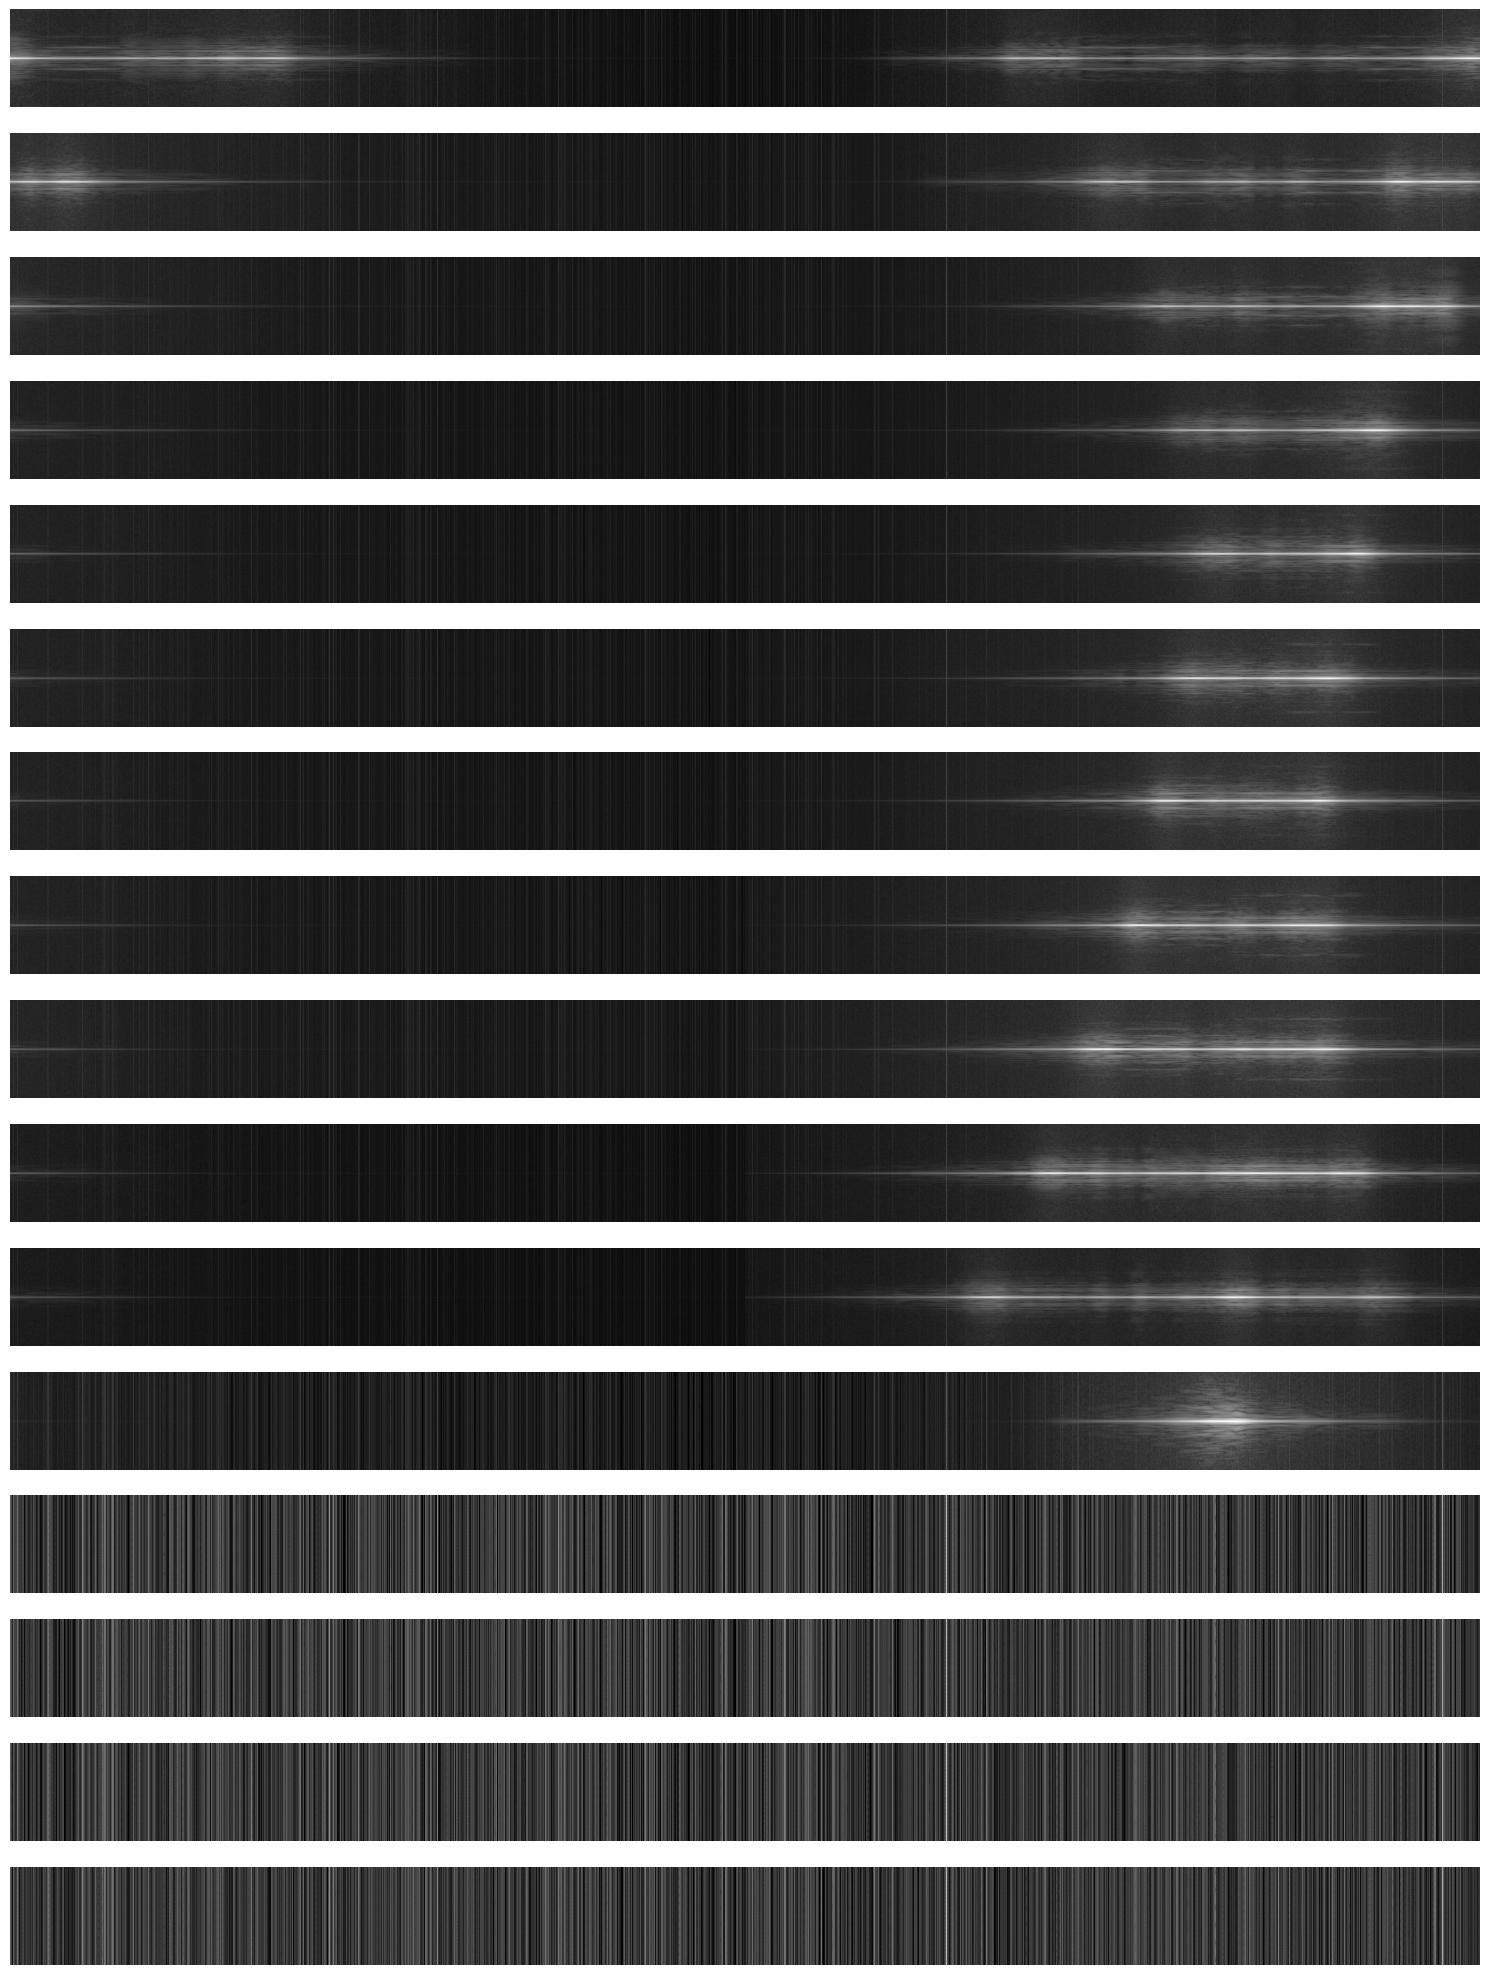

In [67]:
pos_start_mm = 36.0
pos_end_mm = 0.0
pos_step_mm = 0.1
N_steps = int(np.abs(pos_end_mm - pos_start_mm) / pos_step_mm) + 1
positions_mm = np.linspace(pos_start_mm, pos_end_mm, num=N_steps)
plt.figure(figsize=(15,20))
for i in range(16):
    fft_image = np.fft.fftshift(np.fft.fft(data_list[20*i], axis = 0))
    max_pt = np.unravel_index(np.argmax(np.abs(fft_image)), fft_image.shape)
    plt.subplot(16,1,i+1)
    # focus in the center of the image
    plt.imshow(np.abs(fft_image[400:600,:])**0.2, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
print(np.max(np.abs(fft_image)))

1295099.0


In [50]:
# magnification of the WFS camera setup
mag = 5
# pixel size of the camera in microns
px_cam_m = 2.4e-6
# effective pixel size in the sample plane
px_img_m = px_cam_m/mag
stride_px = 0.1e-3/px_img_m
#print(f"Pixel stride in pixels: {stride_px:.1f} px")


# Calculate the height of the composite image
composite_height = int(data_list[0].shape[0] + (len(data_list) - 1) * stride_px)
composite_width = data_list[0].shape[1]

# Create an empty array for the composite image
composite_image = np.zeros((composite_height, composite_width), dtype=data_list[0].dtype)

x_composite_um = np.arange(composite_width)*px_img_m
y_composite_um = np.arange(composite_height)*px_img_m

# Add each image to the composite image with the specified vertical displacement
for idx, image in enumerate(data_list):
    start_y = int(idx * stride_px)
    end_y = start_y + image.shape[0]
    composite_image[start_y:end_y, :] += image

plt.imsave('../data/20260310_ALS531_WFS/linear_composite_image.png', composite_image.T, cmap='gray')

Pixel stride in pixels: 208.3 px


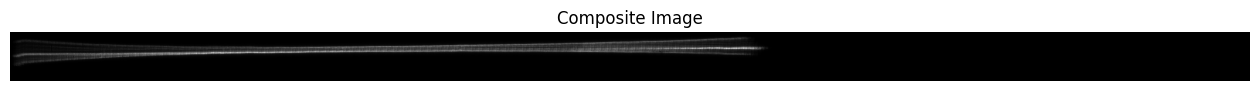

In [48]:
# Display the composite image
plt.figure(figsize=(16, 5))
plt.imshow(composite_image.T, cmap='gray')
plt.xlabel('linear stage position (a.u.)')
plt.ylabel('vertical position (a.u.)')
plt.title('Composite Image')
plt.axis('off')
plt.show()

## Setting up epics/ophyd/bluesky/tiled

In [68]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')

In [170]:
Obender.low_limit_travel.set(-2000)

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_bend_um.LLM', name='bender_um_low_limit_travel', parent='bender_um', value=-2000, timestamp=1773181423.4237747, tolerance=1e-05, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_bend_um.LLM', limits=False, put_complete=False), done=False, success=False)

In [ ]:
from epics import EpicsSignal, EpicsSignalRO
from ophyd import Component as Cpt, Device
from ophyd.areadetector import PvaDetector

class Camera(Device):
    acquire = Cpt(EpicsSignal, 'Acquire')
    acquire_rbv = Cpt(EpicsSignalRO, 'Acquire_RBV')
    array_data = Cpt(EpicsSignal, 'ArrayData')
    array_size_x = Cpt(EpicsSignalRO, 'ArraySizeX_RBV')
    array_size_y = Cpt(EpicsSignalRO, 'ArraySizeY_RBV')
    array_size_z = Cpt(EpicsSignalRO, 'ArraySizeZ_RBV')
    image_mode = Cpt(EpicsSignal, 'ImageMode')
    trigger_mode = Cpt(EpicsSignal, 'TriggerMode')
    exposure_time = Cpt(EpicsSignal, 'AcquireTime')
    exposure_time_rbv = Cpt(EpicsSignalRO, 'AcquireTime_RBV')

# Example instantiation
camera = Camera('BL531acA5427:cam1:', name='camera')

In [15]:
from ophyd import ADComponent
from ophyd import ImagePlugin
from ophyd import SingleTrigger
from ophyd import Component, DetectorBase, CamBase, EpicsSignal, EpicsSignalRO
from ophyd.areadetector.filestore_mixins import FileStoreTIFFIterativeWrite
from ophyd.areadetector.plugins import TIFFPlugin
import os

BASLER_FILES_ROOT = "/mnt/data531"
BASLER_TEST_IMAGE_DIR = "20251113_test/%Y/%m/%d"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs


############### Basler TIFF Plugin ################

class BaslerTIFFPlugin(FileStoreTIFFIterativeWrite, TIFFPlugin):

    def describe(self):
        ret = super().describe()
        key = self.parent._image_name

        color_mode = self.parent.cam.color_mode.get(as_string=True)
        num_images = self.parent.cam.num_images.get()
        height = self.array_size.height.get()
        width  = self.array_size.width.get()

        if color_mode == 'Mono':
            ret[key]['shape'] = [num_images, height, width]
        elif color_mode in ['RGB1', 'Bayer']:
            ret[key]['shape'] = [num_images, height, width, 3]
        else:
            raise RuntimeError(f"Unexpected color_mode: {color_mode!r}")

        # dtype mapping
        cam_dtype = self.data_type.get(as_string=True)
        type_map = {
            'UInt8':   '|u1',
            'UInt16':  '<u2',
            'Float32': '<f4',
            'Float64': '<f8',
            'Int32':   '<i4',
        }
        if cam_dtype in type_map:
            ret[key].setdefault('dtype_str', type_map[cam_dtype])

        return ret


############### Basler Cam ################

class BaslerCam(CamBase):
    """
    Basler camera CAM plugin.
    Extends CamBase with Basler-specific PVs.
    CamBase already provides: acquire, acquire_time, acquire_period,
    num_images, image_mode, trigger_mode, color_mode, data_type, etc.
    Only add PVs that CamBase does NOT already define.
    """

    # Basler-specific PVs not in CamBase
    pixel_format  = Component(EpicsSignal,   'PixelFormat',  string=True)
    gain          = Component(EpicsSignal,   'Gain')
    exposure_auto = Component(EpicsSignal,   'ExposureAuto', string=True)
    gain_auto     = Component(EpicsSignal,   'GainAuto',     string=True)

    # Readback for acquire so SingleTrigger can poll it
    acquire_rbv   = Component(EpicsSignalRO, 'Acquire_RBV')


############### Basler Detector ################

class BaslerDetector(SingleTrigger, DetectorBase):
    """
    Complete Basler area-detector device.
    Uses SingleTrigger mixin so bp.count() / bp.scan() work out of the box.
    """

    cam   = ADComponent(BaslerCam,          'cam1:')
    image = ADComponent(ImagePlugin,        'image1:')
    tiff  = ADComponent(
        BaslerTIFFPlugin,
        'TIFF1:',
        write_path_template=os.path.join(BASLER_FILES_ROOT, BASLER_TEST_IMAGE_DIR),
        read_path_template=os.path.join(BASLER_FILES_ROOT, BASLER_TEST_IMAGE_DIR),
    )


############### Instantiation ################

try:
    basler_camera = BaslerDetector('BL531acA5427:', name='basler_camera')

    # Stage signals — set before each acquisition, restored after
    basler_camera.cam.stage_sigs['image_mode']    = 'Single'
    basler_camera.cam.stage_sigs['num_images']    = 1
    basler_camera.cam.stage_sigs['acquire_time']  = 1
    basler_camera.cam.stage_sigs['acquire_period'] = 1

    basler_camera.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_camera.tiff.stage_sigs['enable']        = 1
    basler_camera.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_camera.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_camera.read_attrs      = ['tiff']
    basler_camera.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

Basler camera connected successfully.


In [3]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})


# Send all metadata/data captured to the BestEffortCallback.


from databroker.v2 import temp
db = temp()

# Insert all metadata/data captured into db.
RE.subscribe(db.v1.insert)


from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri
#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
# tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)



[BCSMotor] bcs_linear_motor reached 4.9972, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.0000
[BCSMotor] bcs_linear_motor reached 5.0925, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.1000
[BCSMotor] bcs_linear_motor reached 5.1994, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.2000
[BCSMotor] bcs_linear_motor reached 5.2932, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.3000
[BCSMotor] bcs_linear_motor reached 5.3996, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.4000
[BCSMotor] bcs_linear_motor reached 5.4972, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.5000
[BCSMotor] bcs_linear_motor reached 5.5990, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.6000
Deferred pause acknowledged. Continuing to checkpoint.
[BCSMotor] bcs_linear_motor reached 4.9988, settling for 0.5s...
[BCSMotor] bcs_linear_moto

DeviceStatus(device=bcs_linear_motor, done=False, success=False) has timed out


In [150]:
from bluesky.plans import (
    count
)
RE(count([basler_camera], num=2))



Transient Scan ID: 1     Time: 2026-03-10 15:08:15
Persistent Unique Scan ID: 'cae7ebf0-9a4e-48a8-8541-1ed1cc64e318'
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 15:08:19.5 |
|         2 | 15:08:24.1 |
+-----------+------------+
generator count ['cae7ebf0'] (scan num: 1)





('cae7ebf0-9a4e-48a8-8541-1ed1cc64e318',)

In [151]:
uid = 'cae7ebf0-9a4e-48a8-8541-1ed1cc64e318'
db = tiled_client[uid]
print(db['primary']['basler_camera_image'].read())

[[[ 6  3  2 ...  6  1  4]
  [ 4  3  5 ...  7  3  5]
  [ 4  7  3 ...  4  4  4]
  ...
  [ 2  3  1 ...  4  5  2]
  [ 3  1  4 ...  2  2  2]
  [ 3  0  1 ...  1  6  1]]

 [[ 1  6  2 ...  2  1  2]
  [ 8  3  6 ...  4  5  3]
  [ 5  4 10 ...  2  3  2]
  ...
  [ 1  1  2 ...  3  0  3]
  [ 2  4  0 ...  4  1  5]
  [ 0  1  2 ...  4  1  4]]]


We had issues with a leading slash in the tiff plugin for the IOC that threw a wrench at Henry's beautiful ophyd class for the basler camera. BE VERY CAREFUL

In [ ]:
uid = 'bfd576a3-7d33-4783-bc9d-004f7d5e2a7a'
db = tiled_client[uid]
client = db['primary']['basler_camera_image']
db['primary']['basler_camera_image'].data_sources()
# see that /10ec should have been 10/ec et voila


[DataSource(structure_family='array', structure={'data_type': {'endianness': 'little', 'kind': 'u', 'itemsize': 2, 'dt_units': None}, 'chunks': [[1, 1], [1000], [3000]], 'shape': [2, 1000, 3000], 'dims': None, 'resizable': False}, id=7189, mimetype='multipart/related;type=image/tiff', parameters={}, assets=[Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10e515d7fc-955c-4d1b-b039_000.tif', is_directory=False, parameter='data_uris', num=1, id=60869), Asset(data_uri='file://localhost/mnt/data531/20251113_test/2026/03/10e515d7fc-955c-4d1b-b039_001.tif', is_directory=False, parameter='data_uris', num=2, id=60870)], management='external')]

In [ ]:
# Read all events as a single numpy array
print(client)
import tifffile as tiff
image = tiff.imread('/mnt/data531/20251113_test/2026/03/10/ec7a8358-1f0d-44f7-9e85_001.tif')
import matplotlib.pyplot as plt
plt.imshow(image, cmap='gray')

## Bender scan at position 13
We think we're on row 5 with 7 um shearing grating

In [171]:
from bluesky.plans import scan

RE(scan([basler_camera], Obender, -2000, -1000, 11))



Transient Scan ID: 4     Time: 2026-03-10 15:24:13
Persistent Unique Scan ID: 'd43ecc8f-bd2d-479f-8971-3f2b7f400b73'
New stream: 'primary'
+-----------+------------+------------+
|   seq_num |       time |  bender_um |
+-----------+------------+------------+
|         1 | 15:24:39.8 | -1999.98309 |
|         2 | 15:24:47.7 | -1900.01820 |
|         3 | 15:24:55.2 | -1800.01515 |
|         4 | 15:25:02.6 | -1700.01687 |
|         5 | 15:25:10.1 | -1600.01541 |
|         6 | 15:25:17.5 | -1500.01554 |
|         7 | 15:25:25.0 | -1400.01408 |
|         8 | 15:25:32.5 | -1300.01262 |
|         9 | 15:25:40.0 | -1200.01275 |
|        10 | 15:25:47.4 | -1100.01129 |
|        11 | 15:25:54.9 | -1000.01142 |
+-----------+------------+------------+
generator scan ['d43ecc8f'] (scan num: 4)





('d43ecc8f-bd2d-479f-8971-3f2b7f400b73',)

In [ ]:
uid = 'd43ecc8f-bd2d-479f-8971-3f2b7f400b73'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()


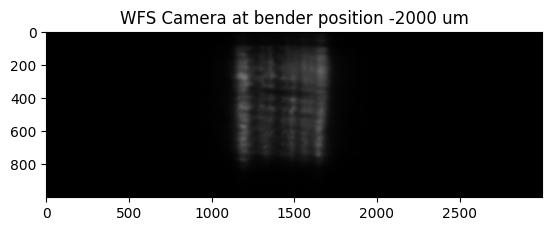

In [175]:
i_b = 0
plt.imshow(images[i_b], cmap='gray')## Bender scan at position 13
plt.title('WFS Camera at bender position %+03.0f um' %bends_um[i_b])

plt.show()
#We think we're on row 5 with 7 um shearing grating

## Energy scan 

In [4]:
import sys
sys.path.append('/home/bl531/python/bluesky-web/queue-server/startup_bl531/')

from h01 import mono_energy

CA.Client.Exception...............................................
    Context: "Channel: "bl201-beamstop:current", Connecting to: 192.168.10.124:42605, Ignored: 192.168.10.124:41021"
    Source File: modules/ca/src/client/cac.cpp line 1320
    Current Time: Tue Mar 10 2026 17:05:21.487672764
..................................................................


cannot connect to dxpMercury:PresetMode


In [ ]:
# default position of the bender is -1800 um, so we can move it back there to start
Obender.move(-1800)

MoveStatus(done=True, pos=bender_um, elapsed=10.4, success=True, settle_time=0.0)

In [183]:
uid = RE(scan([basler_camera], mono_energy, 6000, 8000, 11))



Transient Scan ID: 5     Time: 2026-03-10 15:34:53
Persistent Unique Scan ID: '5c28f39b-6fd2-4c14-a7a8-e4ffff5ce8a2'
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 15:35:48.4 |              5999.837 |                25.6880 |
|         2 | 15:35:59.7 |              6199.850 |                25.0440 |
|         3 | 15:36:10.0 |              6400.021 |                24.4420 |
|         4 | 15:36:19.8 |              6599.965 |                23.8790 |
|         5 | 15:36:29.4 |              6799.789 |                23.3510 |
|         6 | 15:36:38.7 |              6999.820 |                22.8540 |
|         7 | 15:36:47.7 |              7199.754 |                22.3860 |
|         8 | 15:36:56.3 |              7399.825 |                21.9440 |
|         9 | 15:37:04.

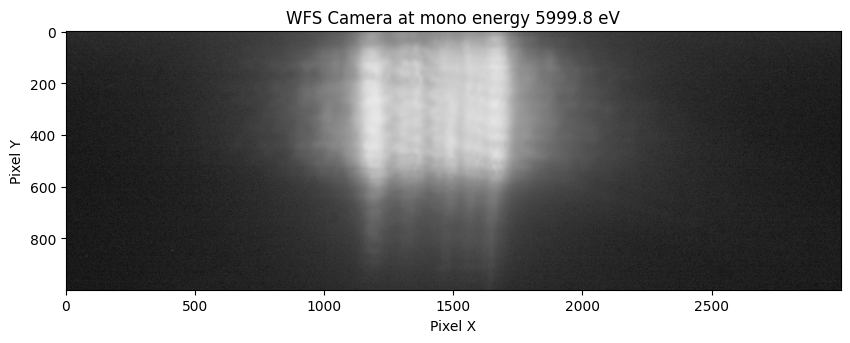

In [187]:
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy = db['primary']['mono_energy_energy_eV'].read()
plt.figure(figsize=(10, 5))
plt.imshow(np.log(images[-5]+1), cmap='gray')
plt.title('WFS Camera at mono energy %.1f eV' %mono_energy[0])
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

In [5]:
import time
import threading
import re
import numpy as np
from ophyd import Device, Component
from ophyd.signal import Signal
from ophyd.status import DeviceStatus


# ============================================================
# Helper: parse LabView float responses safely
# ============================================================

def parse_labview_float(s):
    """Parse a LabView TCP response like '10.000000' or '0.000000!0' to float."""
    s = str(s).strip()
    m = re.match(r'^[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
    if m:
        return float(m.group(0))
    raise ValueError(f"Cannot parse float from {s!r}")


# ============================================================
# BCS Linear Motor ophyd Device
# ============================================================

class BCSMotor(Device):
    """
    Ophyd Device wrapping a single BCS LabView TCP motor axis.

    Parameters
    ----------
    bcs : connection
        Your existing LabView TCP connection object.
    motor_id : str or int
        The motor identifier used by BCS (e.g. bcs_id_linear).
    settle_time : float
        Time in seconds to wait after the motor reaches target before
        marking the move as done. Default is 0.5s.
    tolerance : float
        Position tolerance in engineering units. Default is 0.01.
    name : str
        Ophyd device name.
    """

    def __init__(self, bcs, motor_id, settle_time=0.5, tolerance=0.01, *args, **kwargs):
        super().__init__(prefix='', *args, **kwargs)
        self._bcs = bcs
        self._motor_id = motor_id
        self._settle_time = settle_time
        self._tolerance = tolerance
        self._set_status = None   # holds the current move status

    # ----------------------------------------------------------
    # Position readback
    # ----------------------------------------------------------

    def get(self):
        """Return current motor position as float."""
        raw = self._bcs.GetMotorPos(self._motor_id)
        return parse_labview_float(raw)

    def read(self):
        pos = self.get()
        return {
            self.name: {
                'value': pos,
                'timestamp': time.time(),
            }
        }

    def describe(self):
        return {
            self.name: {
                'source': f'BCS:{self._motor_id}',
                'dtype': 'number',
                'shape': [],
            }
        }

    # ----------------------------------------------------------
    # Move / set
    # ----------------------------------------------------------

    def set(self, target, timeout=120):
        """
        Move the motor to target position.
        Returns a DeviceStatus that completes when the motor
        reaches the target (within tolerance) plus settle time.

        Compatible with bluesky plans via:
            RE(bps.mv(bcs_linear_motor, 10.0))
        """
        st = DeviceStatus(self, timeout=timeout)

        def _move():
            try:
                # Issue the move command
                self._bcs.MoveMotor(self._motor_id, target)
                time.sleep(0.05)   # short delay before first readback (same as your working code)

                # Poll until position is within tolerance
                while True:
                    raw = self._bcs.GetMotorPos(self._motor_id)
                    pos = parse_labview_float(raw)
                    move_raw = self._bcs.getmove(self._motor_id)
                    move_target = parse_labview_float(move_raw.split('!')[0])

                    if np.abs(pos - move_target) <= self._tolerance:
                        break

                    time.sleep(0.05)

                # Settle time
                print(f"[BCSMotor] {self.name} reached {pos:.4f}, settling for {self._settle_time}s...")
                time.sleep(self._settle_time)

                print(f"[BCSMotor] {self.name} done. Final position: {self.get():.4f}")
                st.set_finished()

            except Exception as e:
                st.set_exception(e)

        t = threading.Thread(target=_move, daemon=True)
        t.start()
        return st

    def stop(self, *, success=False):
        """Stop the motor immediately."""
        try:
            self._bcs.StopMotor(self._motor_id)
        except Exception as e:
            print(f"[BCSMotor] stop error: {e}")

    # ----------------------------------------------------------
    # Convenience
    # ----------------------------------------------------------

    @property
    def position(self):
        """Current motor position (float)."""
        return self.get()

    def __repr__(self):
        try:
            pos = self.get()
            return f"BCSMotor(name={self.name!r}, motor_id={self._motor_id!r}, position={pos:.4f})"
        except Exception:
            return f"BCSMotor(name={self.name!r}, motor_id={self._motor_id!r})"

In [6]:
import sys
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

linear stage position is 6.999982 mm
Linear motor position : 6.999982 mm
Rotary motor position : 0.0 deg
BCSMotor(name='bcs_linear_motor', motor_id='Galil x.20 A', position=7.0000)
BCSMotor(name='bcs_rotary_motor', motor_id='Galil x.20 B', position=0.0000)


In [92]:
from ophyd.status import wait as status_wait
import bluesky.plan_stubs as bps
import bluesky.plans as bp

uid = RE(bp.scan([basler_camera], bcs_linear_motor, 0, 10, 3))



Transient Scan ID: 1     Time: 2026-03-10 16:40:43
Persistent Unique Scan ID: '98607e22-8460-4c19-954f-60a760874ffe'
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 16:40:52.7 |
|         2 | 16:41:00.3 |
|         3 | 16:41:07.3 |
+-----------+------------+
generator scan ['98607e22'] (scan num: 1)





CA.Client.Exception...............................................
    Context: "192.168.10.124:36419"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 10 2026 16:41:31.516557831
..................................................................


In [ ]:
bcs_linear_motor.set(5)

DeviceStatus(device=bcs_linear_motor, done=False, success=False)

[BCSMotor] bcs_linear_motor reached 5.0004, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.0000


In [16]:
# scan from energy 5keV to 9keV with 100eV steps while scanning bcs_id_linear from 5 to 30mm in 0.1mm steps
from bluesky.plans import scan
uids = []
for energy in range(5000, 9001, 100):
    mono_energy.move(energy)
    bcs_linear_motor.set(0)
    uid = RE(scan([basler_camera], bcs_linear_motor, 5, 30, 251))
    uids.append(uid)



Transient Scan ID: 4     Time: 2026-03-10 17:12:21
Persistent Unique Scan ID: 'b7c5d16f-7cf9-423c-9dd9-f60e311341f6'
[BCSMotor] bcs_linear_motor reached 4.9908, settling for 0.5s...
[BCSMotor] bcs_linear_motor done. Final position: 5.0000
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 17:12:25.5 |
|         2 | 17:12:28.9 |
|         3 | 17:12:31.7 |
|         4 | 17:12:34.5 |
|         5 | 17:12:37.3 |
|         6 | 17:12:40.1 |
|         7 | 17:12:42.8 |
|         8 | 17:12:45.7 |
|         9 | 17:12:48.5 |
|        10 | 17:12:51.5 |
|        11 | 17:12:54.3 |
|        12 | 17:12:57.1 |
|        13 | 17:12:59.9 |
|        14 | 17:13:03.0 |
|        15 | 17:13:05.8 |
|        16 | 17:13:08.6 |
|        17 | 17:13:11.3 |
|        18 | 17:13:14.1 |
|        19 | 17:13:16.9 |
|        20 | 17:13:19.8 |
|        21 | 17:13:22.7 |
|        22 | 17:13:25.6 |
|        23 | 17:13:28.9 |
|        24 | 17:13:31.7 |
|       

Run aborted
ophyd.utils.errors.StatusTimeoutError: Status DeviceStatus(device=bcs_linear_motor, done=False, success=False) failed to complete in specified timeout.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/bl531/miniconda3/envs/als_bl531/lib/python3.12/site-packages/bluesky/run_engine.py", line 1610, in _run
    msg = self._plan_stack[-1].send(resp)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bl531/miniconda3/envs/als_bl531/lib/python3.12/site-packages/bluesky/preprocessors.py", line 1399, in __call__
    return (yield from plan)
            ^^^^^^^^^^^^^^^
  File "/home/bl531/miniconda3/envs/als_bl531/lib/python3.12/site-packages/bluesky/preprocessors.py", line 1250, in baseline_wrapper
    return (yield from plan)
            ^^^^^^^^^^^^^^^
  File "/home/bl531/miniconda3/envs/als_bl531/lib/python3.12/site-packages/bluesky/preprocessors.py", line 863, in monitor_during_wrapper
    return (yield 

FailedStatus: DeviceStatus(device=bcs_linear_motor, done=True, success=False)

In [17]:
uids

[('b7c5d16f-7cf9-423c-9dd9-f60e311341f6',),
 ('5565e5d4-c321-4cd0-bee3-7ebaf4295160',),
 ('883251b0-801c-494b-ba9f-15535d13e1a4',),
 ('c1b80daf-99af-4f22-a78e-bd03c7108eb1',),
 ('63eb7f10-cbbe-4a4d-b5eb-11bce9efd93f',),
 ('8647b259-cfbe-4ebe-be8b-3080cdb165fb',),
 ('9463896a-344e-4f26-ada3-695091e87de2',),
 ('614bfece-7d82-4f1a-bf01-27e940c72704',),
 ('84e4d335-7d6a-429e-b938-aaffeea0d2d4',),
 ('353ab5ad-6616-48b0-8cc2-2c4f9fca499e',),
 ('9ac5930e-88f3-4aab-954e-57b8992e9e2f',),
 ('6e2783ed-5b28-47ee-b0d7-daf13a7c8e74',),
 ('dca0f5c3-9838-484d-8282-459ffd2b6ba3',),
 ('a4fa6d70-4366-425f-869a-c36dcbdb3cfb',),
 ('ac014e68-909c-4b10-9459-fe9dcddd487c',),
 ('0ad43001-df61-429c-8d13-7ae0707c880a',),
 ('3a6002ef-b88f-4f4c-bd1b-551a21ab8eee',),
 ('cfcc755f-05c8-412d-9c28-0ee5c6580eb0',),
 ('7d8f7b63-56e5-4616-846e-fffe28b1344e',),
 ('39b376da-0ed4-4e14-8151-7430a423aa7e',),
 ('8660e1cc-c3a7-44d7-92a2-4140803bcd55',),
 ('a75b15d2-7012-4ad2-9db2-bacce2549142',),
 ('c43fbd01-d70d-444a-bf23-5c29f

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(np.log(images[120]+1), cmap='gray')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

In [ ]:
# magnification of the WFS camera setup
mag = 5
# pixel size of the camera in microns
px_cam_m = 2.4e-6 * 2 # we bin 2x2, so effective pixel size on camera is 4.8 um
# effective pixel size in the sample plane
px_img_m = px_cam_m/mag
stride_px = 0.1e-3/px_img_m
#print(f"Pixel stride in pixels: {stride_px:.1f} px")
energy_list = np.arange(5000, 9001, 100)

for idx_uid, uid in enumerate(uids):
    db = tiled_client[uid]
    data_list = db['primary']['basler_camera_image'].read()
    # Calculate the height of the composite image
    composite_height = int(data_list[0].shape[0] + (len(data_list) - 1) * stride_px)
    composite_width = data_list[0].shape[1]

    # Create an empty array for the composite image
    composite_image = np.zeros((composite_height, composite_width), dtype=data_list[0].dtype)

    x_composite_um = np.arange(composite_width)*px_img_m
    y_composite_um = np.arange(composite_height)*px_img_m

    # Add each image to the composite image with the specified vertical displacement
    for idx, image in enumerate(data_list):
        start_y = int(idx * stride_px)
        end_y = start_y + image.shape[0]
        composite_image[start_y:end_y, :] += image

    plt.imsave('../data/20260310_ALS531_WFS/linear_composite_image_%04d.png' %energy_list[idx_uid], composite_image.T, cmap='gray')

CA.Client.Exception...............................................
    Context: "192.168.10.124:42349"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Wed Mar 11 2026 10:44:22.068779220
..................................................................


In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(np.log(images[105]+1), cmap='gray')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()